C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-23 12:36:22] [ELAPSED 00:00:00] スクリプト開始
[2026-04-23 12:36:22] [ELAPSED 00:00:00] START TIME = 2026-04-23 12:36:22
[2026-04-23 12:36:22] [ELAPSED 00:00:00] 乱数シード設定: seed=42
[2026-04-23 12:36:22] [ELAPSED 00:00:00] [START] 入力ファイル確認
[2026-04-23 12:36:22] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_features.txt
[2026-04-23 12:36:22] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_classes.txt
[2026-04-23 12:36:22] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_edgelist.txt
[2026-04-23 12:36:22] [ELAPSED 00:00:00] [END] 入力ファイル確認 | phase_elapsed=00:00:00
[2026-04-23 12:36:22] [ELAPSED 00:00:00] [START] 生データ読み込み
[2026-04-23 12:36:22] [ELAPSED 00:00:00] txs_features 読み込み中...
[2026-04-23 12:36:33] [ELAPSED 00:00:10] txs_features 読み込み完了: shape=(203769, 184)
[2026-04-23 12:36:33] [ELAPSED 00:00:10] txs_classes 読み込み中...
[2026-04-23 12:36:33] [ELAPSED 00:00:11] txs_classes 読み込み完了: shape=(203769, 2)
[2026-04-23 12:36:33] [ELAPSED 00:00:11] txs_edgelist 読み込み中...
[2026-04-23 12:36:34] [ELAPSED 00:00:

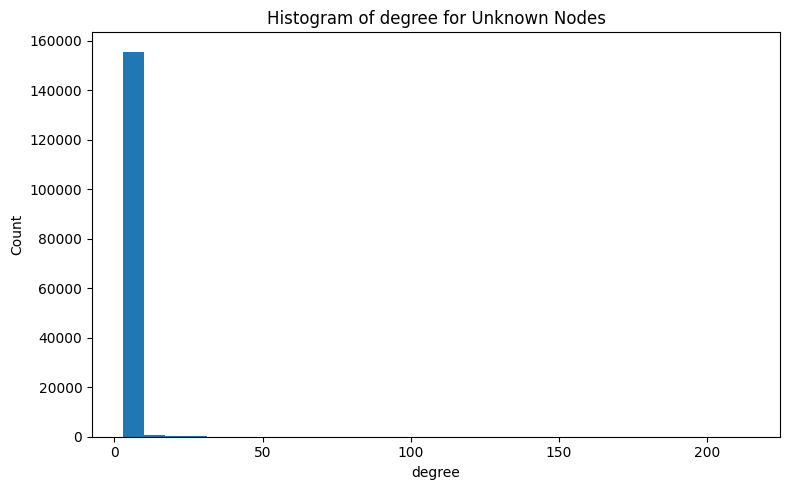

[2026-04-23 12:54:11] [ELAPSED 00:17:48] ヒストグラム描画中: degree_centrality


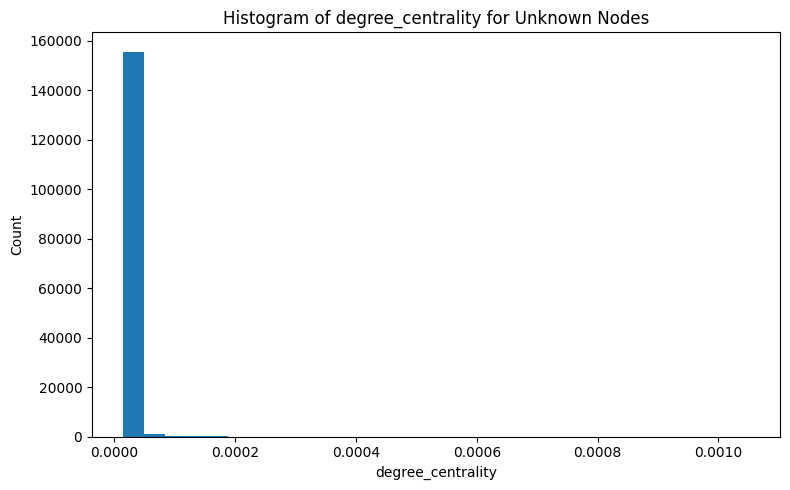

[2026-04-23 12:54:12] [ELAPSED 00:17:49] ヒストグラム描画中: closeness_centrality


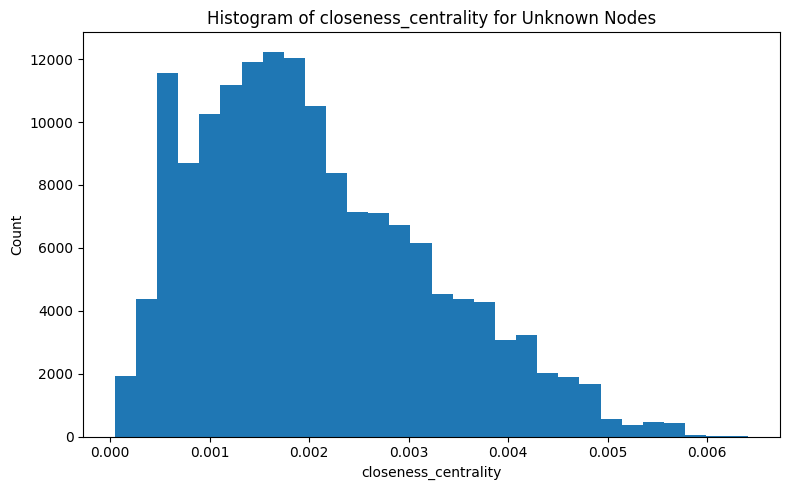

[2026-04-23 12:54:12] [ELAPSED 00:17:49] ヒストグラム描画中: betweenness_centrality


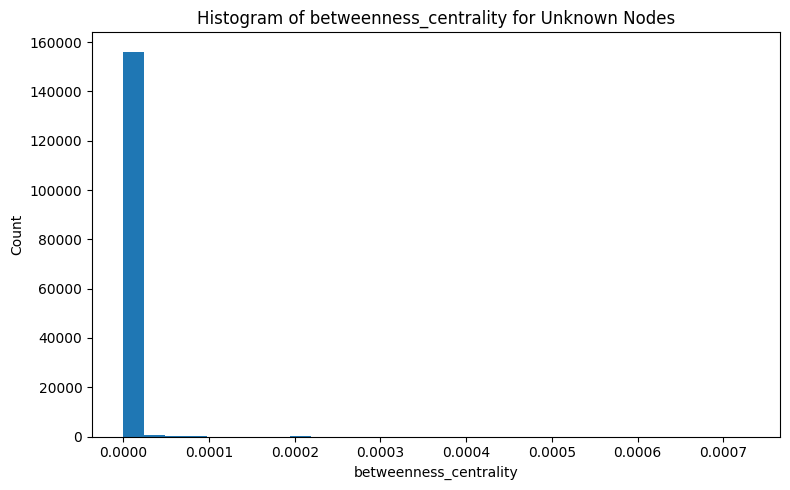

[2026-04-23 12:54:12] [ELAPSED 00:17:49] ヒストグラム描画中: pagerank


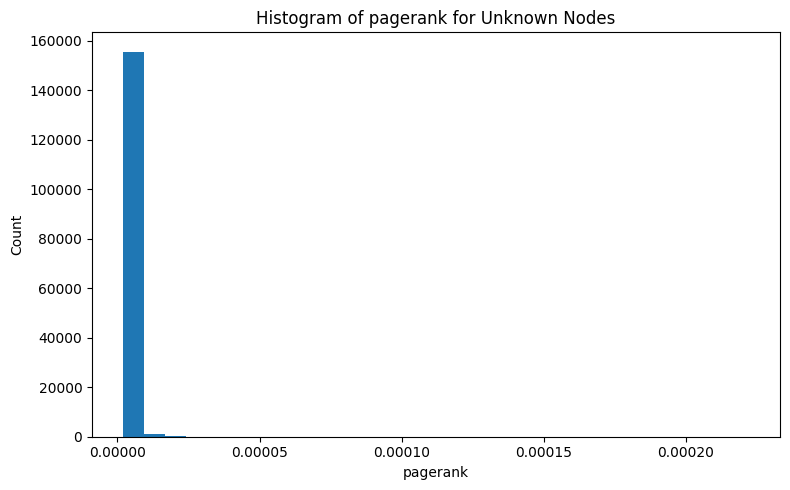

[2026-04-23 12:54:12] [ELAPSED 00:17:50] ヒストグラム描画中: eigenvector_centrality


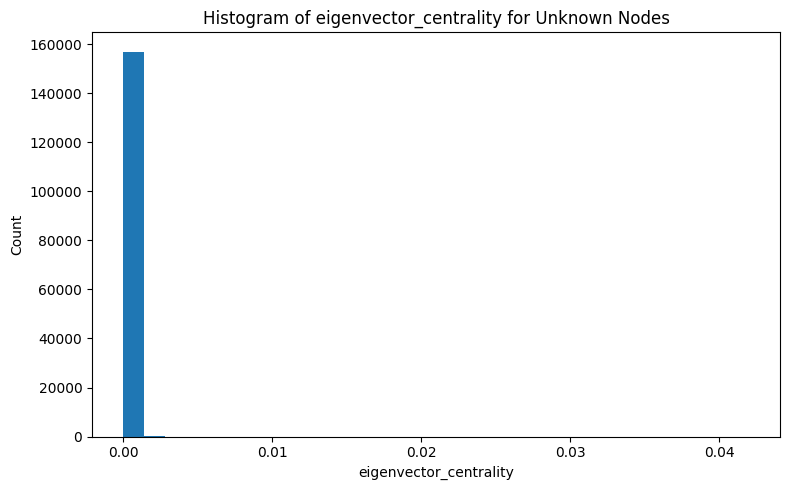

[2026-04-23 12:54:13] [ELAPSED 00:17:50] [END] unknown ノード中心性ヒストグラム | phase_elapsed=00:00:01
[2026-04-23 12:54:13] [ELAPSED 00:17:50] [START] time step ごとの unknown 集計

=== time step ごとの unknown ノード集計 ===
 time_step  unknown_count  avg_degree  avg_degree_centrality  avg_closeness  avg_betweenness  avg_pagerank  avg_eigenvector
         1           5733    4.180359               0.000021       0.003678     1.876617e-06      0.000005     9.726967e-07
         2           3427    4.144733               0.000020       0.001566     1.480778e-06      0.000005     3.997228e-09
         3           5342    4.526956               0.000022       0.000523     5.980302e-06      0.000005     4.429464e-07
         4           4253    4.703503               0.000023       0.002257     1.807916e-06      0.000005     3.404570e-06
         5           4921    4.514326               0.000022       0.003312     1.952861e-06      0.000005     5.397067e-07
         6           3843    4.369503               

In [1]:
"""
Elliptic++ っぽいトランザクショングラフに対して、
unknown ノード（class=3）を分析し、
GNN 学習前に複数中心性を計算・表示する完全版。

機能
1) txs_features / txs_classes / txs_edgelist を読み込む
2) class=3 を unknown として扱う
3) PyG Data を構築
4) unknown ノード数を集計
5) unknown ノードについて複数中心性を計算
   - degree
   - degree_centrality
   - closeness_centrality
   - betweenness_centrality
   - pagerank
   - eigenvector_centrality
6) 各中心性トップ10を表示
7) 現在時刻付きで途中経過を詳しく表示
8) GNN 学習へ進む前に y/N 確認
"""

import random
import warnings
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, to_networkx

warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

SEED = 42

# 特徴量
INCLUDE_TIME_STEP_AS_FEATURE = False

# 表示件数
TOP_K = 10

# GNN 前の確認
ASK_BEFORE_TRAIN = True

# 中心性設定
USE_APPROX_BETWEENNESS = True     # True: 近似媒介中心性, False: 厳密媒介中心性
BETWEENNESS_K = 100               # 近似媒介中心性で使うサンプル数
EIGENVECTOR_MAX_ITER = 1000

# ヒストグラム
DRAW_HIST = True
HIST_BINS = 30
FIGSIZE = (8, 5)

# CSV 保存
SAVE_CSV = False
OUTPUT_CSV = "unknown_nodes_centrality.csv"


# ==========================
# ログ
# ==========================
GLOBAL_START_TIME = None


def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def format_seconds(sec: float) -> str:
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def log(msg: str):
    global GLOBAL_START_TIME
    if GLOBAL_START_TIME is None:
        print(f"[{now_str()}] {msg}")
    else:
        elapsed = time.time() - GLOBAL_START_TIME
        print(f"[{now_str()}] [ELAPSED {format_seconds(elapsed)}] {msg}")


class PhaseTimer:
    def __init__(self, name: str):
        self.name = name
        self.start = None

    def __enter__(self):
        self.start = time.time()
        log(f"[START] {self.name}")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.time() - self.start
        log(f"[END] {self.name} | phase_elapsed={format_seconds(elapsed)}")


# ==========================
# 基本
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    log(f"乱数シード設定: seed={seed}")


def check_files():
    with PhaseTimer("入力ファイル確認"):
        for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
            if not Path(path).exists():
                raise FileNotFoundError(f"ファイルが見つかりません: {path}")
            log(f"確認OK: {path}")


def confirm_continue():
    while True:
        ans = input("\nこの後の GNN 処理へ進みますか？ (y/n): ").strip().lower()
        if ans in ["y", "yes"]:
            log("ユーザー入力: y -> 続行")
            return True
        elif ans in ["n", "no"]:
            log("ユーザー入力: n -> 終了")
            return False
        else:
            print("y か n を入力してください。")


def normalize_class_value(v):
    """
    1 / '1' / 'illicit' -> 0
    2 / '2' / 'licit'   -> 1
    3 / '3' / 'unknown' -> -1
    """
    if pd.isna(v):
        return -1

    s = str(v).strip().lower()

    if s in {"1", "illicit"}:
        return 0
    elif s in {"2", "licit"}:
        return 1
    elif s in {"3", "unknown"}:
        return -1
    else:
        return -1


# ==========================
# 読み込み
# ==========================
def load_raw_data():
    with PhaseTimer("生データ読み込み"):
        log("txs_features 読み込み中...")
        df_features = pd.read_csv(TXS_FEATURES)
        log(f"txs_features 読み込み完了: shape={df_features.shape}")

        log("txs_classes 読み込み中...")
        df_classes = pd.read_csv(TXS_CLASSES)
        log(f"txs_classes 読み込み完了: shape={df_classes.shape}")

        log("txs_edgelist 読み込み中...")
        df_edges = pd.read_csv(TXS_EDGES)
        log(f"txs_edgelist 読み込み完了: shape={df_edges.shape}")

        print("\n=== Features overview ===")
        print(df_features.head())
        print("missing values (total):", int(df_features.isnull().sum().sum()))

        print("\n=== Classes overview ===")
        if "class" in df_classes.columns:
            print(df_classes["class"].value_counts(dropna=False))

        print("\n=== Edges overview ===")
        print(df_edges.head())
        print("duplicate edges:", int(df_edges.duplicated().sum()))

        return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    include_time_step_as_feature: bool = False
):
    with PhaseTimer("PyG Data 構築"):
        id_col_feat = df_features.columns[0]
        log(f"ノードID列: {id_col_feat}")

        if "Time step" not in df_features.columns:
            raise ValueError("df_features に 'Time step' 列がありません。")

        # Time step
        time_steps_np = pd.to_numeric(
            df_features["Time step"], errors="coerce"
        ).fillna(-1).to_numpy(dtype=np.int64)
        time_steps = torch.tensor(time_steps_np, dtype=torch.long)

        log(f"time step 範囲: min={int(time_steps.min().item())}, max={int(time_steps.max().item())}")

        # 特徴量
        feature_cols = [c for c in df_features.columns if c != id_col_feat]
        if not include_time_step_as_feature:
            feature_cols = [c for c in feature_cols if c != "Time step"]

        log(f"特徴量列数: {len(feature_cols)}")

        x_df = df_features[feature_cols].copy()
        x_df = x_df.apply(pd.to_numeric, errors="coerce")
        x_df = x_df.replace([np.inf, -np.inf], np.nan)
        x_df = x_df.fillna(0.0)

        x_np = x_df.to_numpy(dtype=np.float32)
        x = torch.tensor(x_np, dtype=torch.float)

        log(f"x shape: {tuple(x.shape)}")
        log(f"x に NaN があるか: {torch.isnan(x).any().item()}")
        log(f"x に Inf があるか: {torch.isinf(x).any().item()}")

        # ラベル
        if "class" not in df_classes.columns:
            raise ValueError("df_classes に 'class' 列がありません。")

        if id_col_feat in df_classes.columns:
            id_col_cls = id_col_feat
        else:
            id_col_cls = df_classes.columns[0]
            log(f"class 側 ID 列として '{id_col_cls}' を使用")

        node_ids = df_features[id_col_feat].astype(int).values
        id2idx = {int(nid): i for i, nid in enumerate(node_ids)}
        log(f"ノード数: {len(node_ids)}")

        cls_series = (
            df_classes
            .set_index(id_col_cls)["class"]
            .reindex(node_ids)
        )

        y_np = cls_series.map(normalize_class_value).to_numpy(dtype=np.int64)
        y = torch.tensor(y_np, dtype=torch.long)

        log("ラベル分布:")
        print(pd.Series(y_np).value_counts(dropna=False).sort_index())

        # エッジ
        edge_cols = list(df_edges.columns[:2])
        src_raw = df_edges[edge_cols[0]].values
        dst_raw = df_edges[edge_cols[1]].values

        src_idx = []
        dst_idx = []
        missing_edges = 0

        log(f"元エッジ数: {len(src_raw)}")
        for i, (u, v) in enumerate(zip(src_raw, dst_raw), start=1):
            u = int(u)
            v = int(v)

            if u in id2idx and v in id2idx:
                src_idx.append(id2idx[u])
                dst_idx.append(id2idx[v])
            else:
                missing_edges += 1

            if i % 500000 == 0:
                log(f"エッジ変換進捗: {i}/{len(src_raw)}")

        edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
        edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
        edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

        log(f"edge_index shape: {tuple(edge_index.shape)}")
        log(f"未知ノードによりスキップされたエッジ数: {missing_edges}")

        data = Data(x=x, edge_index=edge_index, y=y)
        data.time_steps = time_steps
        data.node_ids = torch.tensor(node_ids, dtype=torch.long)

        return data


# ==========================
# unknown ノードの複数中心性
# ==========================
def analyze_unknown_nodes_with_more_centralities(
    data: Data,
    top_k: int = 10,
    use_approx_betweenness: bool = True,
    betweenness_k: int = 100
):
    with PhaseTimer("unknown ノード多中心性分析"):
        log("NetworkX グラフへ変換中...")
        G = to_networkx(data.cpu(), to_undirected=True)
        log(f"NetworkX グラフ変換完了: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

        y = data.y.cpu().numpy()
        node_ids = data.node_ids.cpu().numpy()
        time_steps = data.time_steps.cpu().numpy()

        unknown_nodes = np.where(y == -1)[0]
        n_unknown = len(unknown_nodes)

        log(f"unknown ノード数: {n_unknown}")

        if n_unknown == 0:
            print("unknown ノードは存在しません。")
            return pd.DataFrame(), G

        # 次数中心性
        log("次数中心性を計算中...")
        degree_cent = nx.degree_centrality(G)
        log("次数中心性 計算完了")

        # 近接中心性
        log("近接中心性を計算中...")
        closeness_cent = nx.closeness_centrality(G)
        log("近接中心性 計算完了")

        # 媒介中心性
        if use_approx_betweenness:
            log(f"媒介中心性を近似計算中... k={betweenness_k}")
            betweenness_cent = nx.betweenness_centrality(G, k=betweenness_k, seed=SEED)
            log("媒介中心性（近似）計算完了")
        else:
            log("媒介中心性を厳密計算中... かなり重い可能性があります")
            betweenness_cent = nx.betweenness_centrality(G)
            log("媒介中心性（厳密）計算完了")

        # PageRank
        log("PageRank を計算中...")
        pagerank_cent = nx.pagerank(G)
        log("PageRank 計算完了")

        # 固有ベクトル中心性
        log("固有ベクトル中心性を計算中...")
        try:
            eigenvector_cent = nx.eigenvector_centrality(G, max_iter=EIGENVECTOR_MAX_ITER)
            log("固有ベクトル中心性 計算完了")
        except Exception as e:
            log(f"固有ベクトル中心性が収束しなかったため numpy 版へ切替: {e}")
            eigenvector_cent = nx.eigenvector_centrality_numpy(G)
            log("固有ベクトル中心性（numpy版）計算完了")

        rows = []
        log("unknown ノードごとの集計テーブル作成中...")
        for i, n in enumerate(unknown_nodes, start=1):
            rows.append({
                "node_index": int(n),
                "txId": int(node_ids[n]),
                "time_step": int(time_steps[n]),
                "degree": int(G.degree[n]),
                "degree_centrality": float(degree_cent[n]),
                "closeness_centrality": float(closeness_cent[n]),
                "betweenness_centrality": float(betweenness_cent[n]),
                "pagerank": float(pagerank_cent[n]),
                "eigenvector_centrality": float(eigenvector_cent[n]),
            })

            if i % 10000 == 0:
                log(f"unknown ノード集計進捗: {i}/{n_unknown}")

        df_unknown = pd.DataFrame(rows)
        log(f"unknown ノード集計テーブル完成: shape={df_unknown.shape}")

        # 表示
        print(f"\n=== unknown ノード（次数トップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["degree", "degree_centrality", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print(f"\n=== unknown ノード（次数中心性トップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["degree_centrality", "degree", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print(f"\n=== unknown ノード（近接中心性トップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["closeness_centrality", "degree", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print(f"\n=== unknown ノード（媒介中心性トップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["betweenness_centrality", "degree", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print(f"\n=== unknown ノード（PageRankトップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["pagerank", "degree", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print(f"\n=== unknown ノード（固有ベクトル中心性トップ{min(top_k, len(df_unknown))}） ===")
        print(
            df_unknown.sort_values(
                ["eigenvector_centrality", "degree", "node_index"],
                ascending=[False, False, True]
            ).head(top_k).to_string(index=False)
        )

        print("\n=== unknown ノード中心性の基本統計 ===")
        print(df_unknown[
            [
                "degree",
                "degree_centrality",
                "closeness_centrality",
                "betweenness_centrality",
                "pagerank",
                "eigenvector_centrality",
            ]
        ].describe())

        return df_unknown, G


# ==========================
# ヒストグラム
# ==========================
def plot_unknown_centrality_histograms(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("ヒストグラム描画スキップ: unknown ノードなし")
        return

    with PhaseTimer("unknown ノード中心性ヒストグラム"):
        cols = [
            "degree",
            "degree_centrality",
            "closeness_centrality",
            "betweenness_centrality",
            "pagerank",
            "eigenvector_centrality",
        ]

        for col in cols:
            log(f"ヒストグラム描画中: {col}")
            plt.figure(figsize=FIGSIZE)
            plt.hist(df_unknown[col], bins=HIST_BINS)
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.title(f"Histogram of {col} for Unknown Nodes")
            plt.tight_layout()
            plt.show()


# ==========================
# time step 集計
# ==========================
def summarize_unknown_by_time_step(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("time step 集計スキップ: unknown ノードなし")
        return

    with PhaseTimer("time step ごとの unknown 集計"):
        summary = (
            df_unknown.groupby("time_step")
            .agg(
                unknown_count=("node_index", "count"),
                avg_degree=("degree", "mean"),
                avg_degree_centrality=("degree_centrality", "mean"),
                avg_closeness=("closeness_centrality", "mean"),
                avg_betweenness=("betweenness_centrality", "mean"),
                avg_pagerank=("pagerank", "mean"),
                avg_eigenvector=("eigenvector_centrality", "mean"),
            )
            .reset_index()
            .sort_values("time_step")
        )

        print("\n=== time step ごとの unknown ノード集計 ===")
        print(summary.to_string(index=False))


# ==========================
# main
# ==========================
def main():
    global GLOBAL_START_TIME
    GLOBAL_START_TIME = time.time()

    log("スクリプト開始")
    log(f"START TIME = {now_str()}")

    set_seed(SEED)
    check_files()

    df_features, df_classes, df_edges = load_raw_data()

    data = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE
    )

    df_unknown, G = analyze_unknown_nodes_with_more_centralities(
        data=data,
        top_k=TOP_K,
        use_approx_betweenness=USE_APPROX_BETWEENNESS,
        betweenness_k=BETWEENNESS_K
    )

    if SAVE_CSV and len(df_unknown) > 0:
        with PhaseTimer("CSV 保存"):
            df_unknown.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
            log(f"CSV 保存完了: {OUTPUT_CSV}")

    if DRAW_HIST:
        plot_unknown_centrality_histograms(df_unknown)

    summarize_unknown_by_time_step(df_unknown)

    if ASK_BEFORE_TRAIN:
        if not confirm_continue():
            total_elapsed = time.time() - GLOBAL_START_TIME
            log(f"ここで終了します。総経過時間={format_seconds(total_elapsed)}")
            return

    log("この先に GNN 学習処理を接続できます。")
    total_elapsed = time.time() - GLOBAL_START_TIME
    log(f"Done. 総経過時間={format_seconds(total_elapsed)}")


if __name__ == "__main__":
    main()